# 뇌졸중 데이터셋 시각화

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 라이브러리 임포트


In [ ]:
pip install koreanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 46.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

import plotly.express as px # 플롯 패키지
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 뇌졸중_환자_수

*   컬럼명 변경 및 월 별 데이터 삭제
*   0~9 남자, 10~19 여자






In [ ]:
patient =pd.read_csv('/content/뇌졸중_환자_수_성별_연령별_월별__20230817135751.csv')
patient.head()

,성별(1),연령별(1),2021,2021.1,2021.2,2021.3,2021.4,2021.5,2021.6,2021.7,2021.8,2021.9,2021.10,2021.11,2021.12
0,성별(1),연령별(1),계,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
1,전체,계,120305,9666,9219,10141,10168,10784,10455,10153,9904,9874,10100,10088,9753
2,남자,계,66927,5478,5099,5640,5596,5942,5827,5686,5594,5517,5520,5658,5370
3,남자,1세 미만,48,7,6,7,1,4,3,1,2,6,1,6,4
4,남자,1~9세,95,7,11,7,7,13,5,7,4,10,10,4,10


In [ ]:
df_patient = patient.rename(columns={'성별(1)':'성별','연령별(1)':'연령별','2021':'계'})
df_patient.drop(columns=['2021.1','2021.2','2021.3','2021.4','2021.5','2021.6','2021.7','2021.8','2021.9','2021.10','2021.11','2021.12'], inplace= True)


In [ ]:
filtered_data = df_patient.iloc[1:]
filtered_data

,성별,연령별,계
1,전체,계,120305
2,남자,계,66927
3,남자,1세 미만,48
4,남자,1~9세,95
5,남자,10~19세,194
6,남자,20~29세,615
7,남자,30~39세,1705
8,남자,40~49세,4870
9,남자,50~59세,11936
10,남자,60~69세,17923


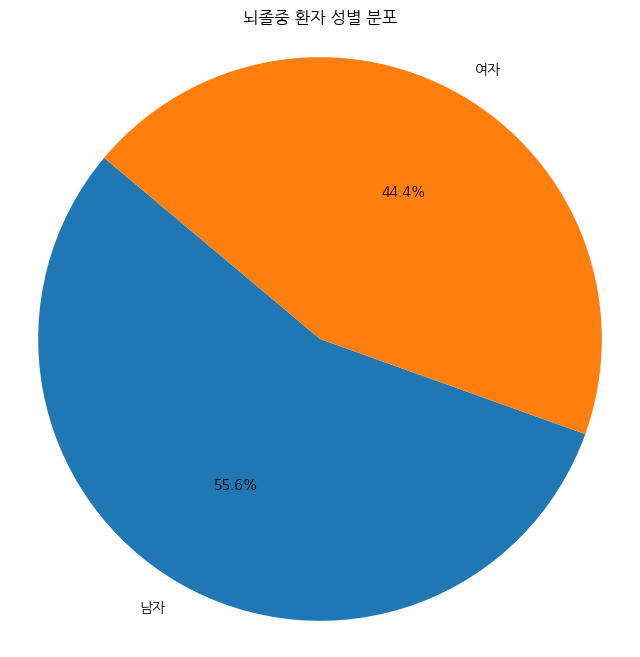

In [ ]:
# 성별 데이터
data = [66927,53378]

# 성별 레이블
labels = ['남자', '여자']

# 파이차트 생성
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # 파이차트를 원형으로 만듦
plt.title("뇌졸중 환자 성별 분포")
plt.show()

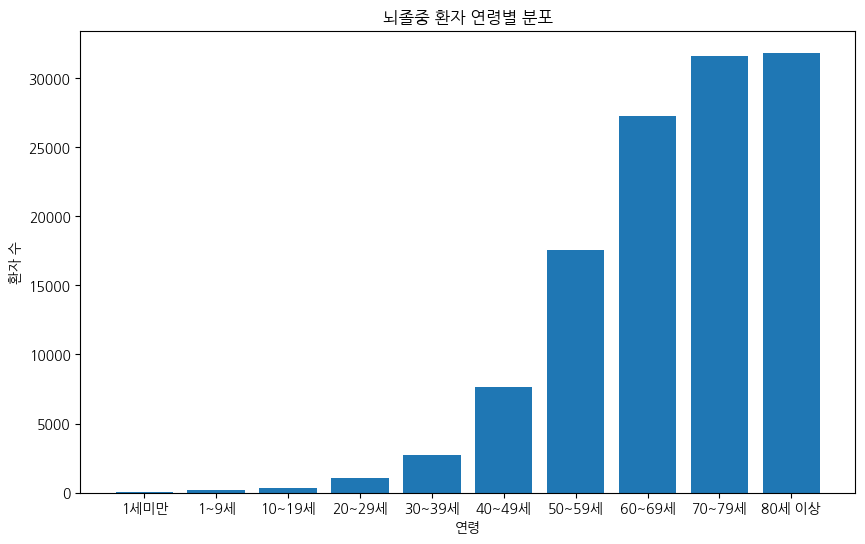

In [ ]:
# 연령 데이터
data = [80,187,346,1092,2746,7661,17519,27242,31611,31821]

# 연령 레이블
labels = ['1세미만', '1~9세','10~19세','20~29세','30~39세','40~49세','50~59세','60~69세','70~79세','80세 이상']

# 바차트 생성
plt.figure(figsize=(10, 6))
plt.bar(labels, data)
plt.title("뇌졸중 환자 연령별 분포")
plt.xlabel("연령")
plt.ylabel("환자 수")
plt.show()

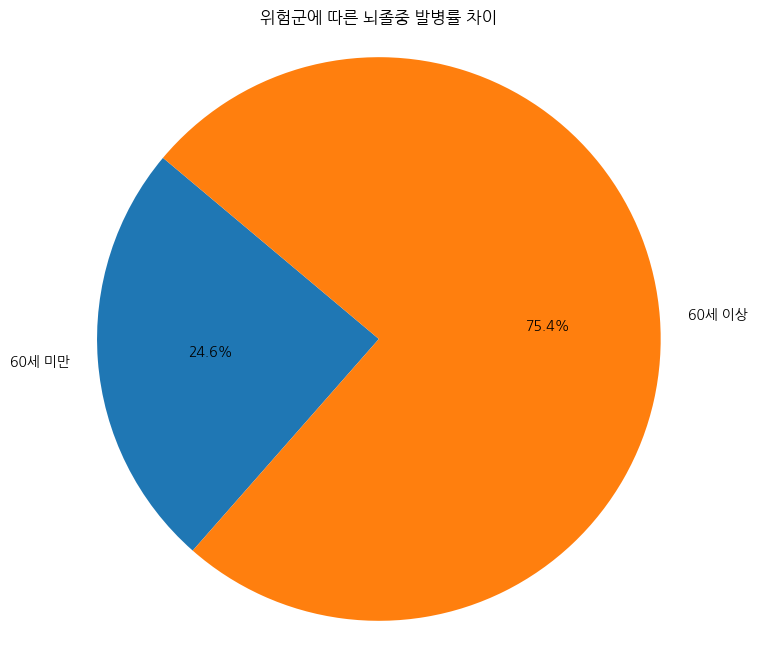

In [ ]:
# 연령 데이터
data = [29631,90674]

# 연령 레이블
labels = ['60세 미만','60세 이상']

# 파이차트 생성
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # 파이차트를 원형으로 만듦
plt.title('위험군에 따른 뇌졸중 발병률 차이')
plt.show()

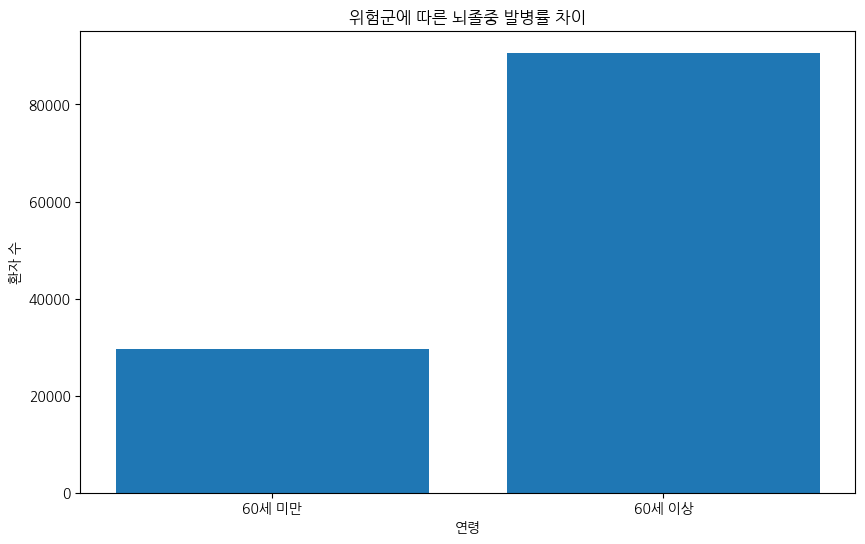

In [ ]:
# 바차트 생성
plt.figure(figsize=(10, 6))
plt.bar(labels, data)
plt.title("위험군에 따른 뇌졸중 발병률 차이")
plt.xlabel("연령")
plt.ylabel("환자 수")
plt.show()

In [ ]:
80+187+346+1092+2746+7661+17519

29631

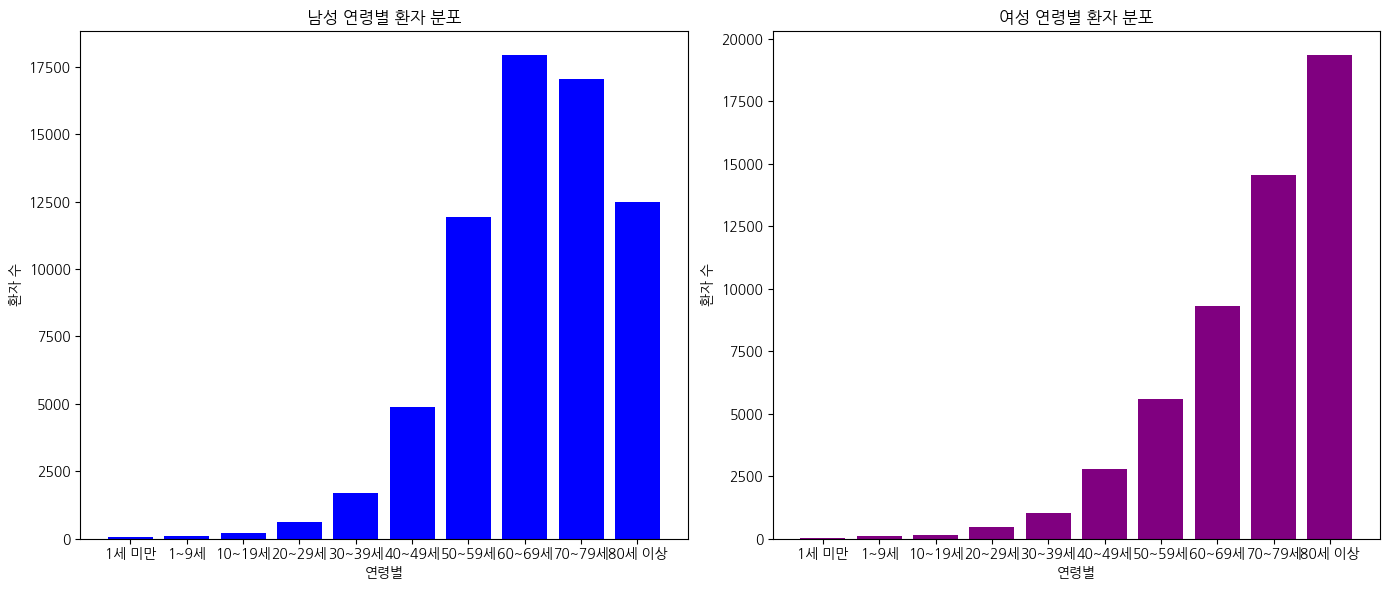

In [ ]:
# 데이터 생성
data = {
    '성별': ['남자', '남자', '남자', '남자', '남자', '남자', '남자', '남자', '남자', '남자', '여자', '여자', '여자', '여자', '여자', '여자', '여자', '여자', '여자', '여자'],
    '연령별': ['1세 미만', '1~9세', '10~19세', '20~29세', '30~39세', '40~49세', '50~59세', '60~69세', '70~79세', '80세 이상', '1세 미만', '1~9세', '10~19세', '20~29세', '30~39세', '40~49세', '50~59세', '60~69세', '70~79세', '80세 이상'],
    '계': [48, 95, 194, 615, 1705, 4870, 11936, 17923, 17047, 12494, 32, 92, 152, 477, 1041, 2791, 5583, 9319, 14564, 19327]
}

# 데이터프레임 생성
df = pd.DataFrame(data)

# 남성 데이터와 여성 데이터 분리
male_data = df[df['성별'] == '남자']
female_data = df[df['성별'] == '여자']

# 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 남성 데이터 그래프
ax1.bar(male_data['연령별'], male_data['계'], color='blue')
ax1.set_title('남성 연령별 환자 분포')
ax1.set_xlabel('연령별')
ax1.set_ylabel('환자 수')

# 여성 데이터 그래프
ax2.bar(female_data['연령별'], female_data['계'], color='purple')
ax2.set_title('여성 연령별 환자 분포')
ax2.set_xlabel('연령별')
ax2.set_ylabel('환자 수')

# 서브플롯 레이아웃 조정
plt.tight_layout()

# 그래프 표시
plt.show()

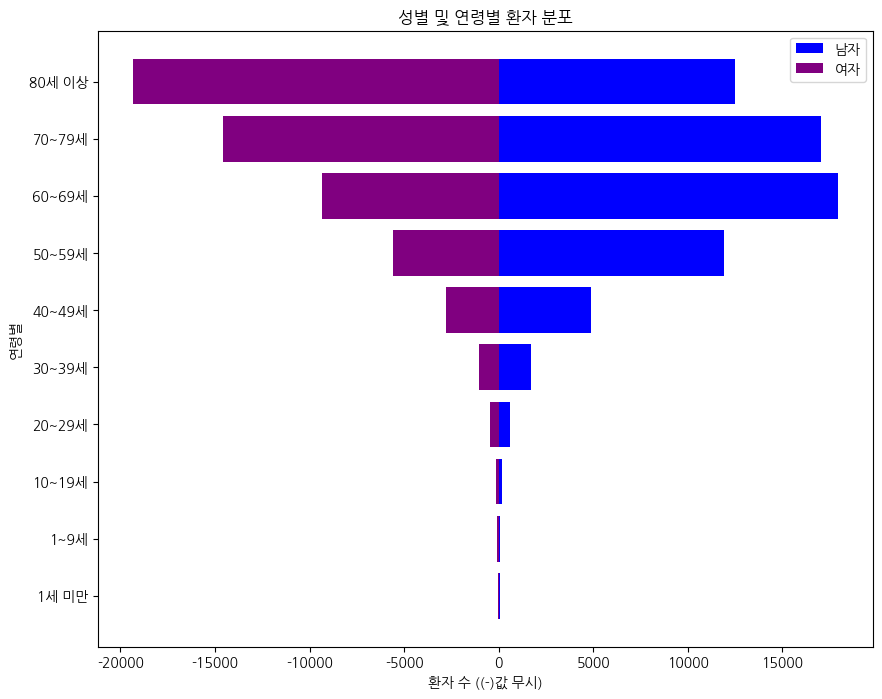

In [ ]:
# 데이터 생성
data = {
    '성별': ['남자', '남자', '남자', '남자', '남자', '남자', '남자', '남자', '남자', '남자', '여자', '여자', '여자', '여자', '여자', '여자', '여자', '여자', '여자', '여자'],
    '연령별': ['80세 이상', '70~79세', '60~69세', '50~59세', '40~49세', '30~39세', '20~29세', '10~19세', '1~9세', '1세 미만', '80세 이상', '70~79세', '60~69세', '50~59세', '40~49세', '30~39세', '20~29세', '10~19세', '1~9세', '1세 미만'],
    '계': [12494, 17047, 17923, 11936, 4870, 1705, 615, 194, 95, 48, 19327, 14564, 9319, 5583, 2791, 1041, 477, 152, 92, 32]
}

# 데이터프레임 생성
df = pd.DataFrame(data)

# 남성 데이터와 여성 데이터 분리
male_data = df[df['성별'] == '남자']
female_data = df[df['성별'] == '여자']

# 그래프 생성
plt.figure(figsize=(10, 8))

# 양방향으로 막대 그래프 생성
plt.barh(male_data['연령별'], male_data['계'], color='blue', label='남자')
plt.barh(female_data['연령별'], -female_data['계'], color='purple', label='여자')

plt.title('성별 및 연령별 환자 분포')
plt.xlabel('환자 수 ((-)값 무시)')
plt.ylabel('연령별')
plt.legend()

# y축 뒤집기 (역순으로 표시)
plt.gca().invert_yaxis()

# 그래프 표시
plt.show()

## 뇌졸중_환자의_응급진료_결과_현황

In [ ]:
outcome = pd.read_csv('/content/뇌졸중_환자의_응급진료_결과_현황_성별_연령별__20230817135859.csv')
outcome.head()

,성별(1),연령별(1),2021,2021.1,2021.2,2021.3,2021.4,2021.5,2021.6
0,성별(1),연령별(1),계,귀가,전원,입원,사망,기타,미상/미입력
1,전체,계,120305,15885,6016,97668,623,113,-
2,남자,계,66927,8492,3198,54865,311,61,-
3,남자,1세 미만,48,7,4,37,-,-,-
4,남자,1~9세,95,20,10,65,-,-,-


In [ ]:
outcome.columns

Index(['성별(1)', '연령별(1)', '2021', '2021.1', '2021.2', '2021.3', '2021.4',
       '2021.5', '2021.6'],
      dtype='object')

In [ ]:
df_outcome = outcome.rename(columns={'2021':'계','2021.1':'귀가','2021.2':'전원','2021.3':'입원','2021.4':'사망','2021.5':'기타'})
df_outcome.drop(columns=['성별(1)','연령별(1)','2021.6'], inplace= True)

In [ ]:
filtered_data = df_outcome.iloc[[1]]
filtered_data

,계,귀가,전원,입원,사망,기타
1,120305,15885,6016,97668,623,113


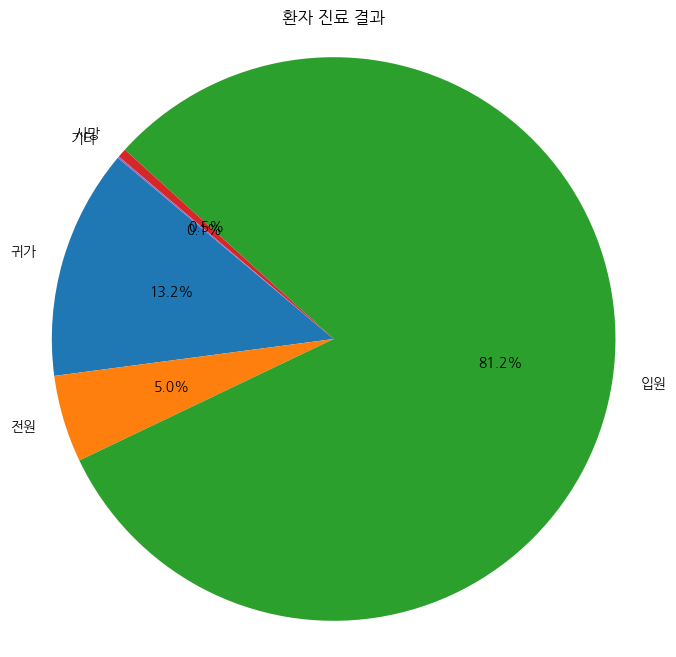

In [ ]:
# 데이터
data = [15885, 6016	, 97668, 623, 113]

# 레이블
labels = ['귀가', '전원', '입원', '사망', '기타']

# 파이차트 생성
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # 파이차트를 원형으로 만듦
plt.title("환자 진료 결과")
plt.show()

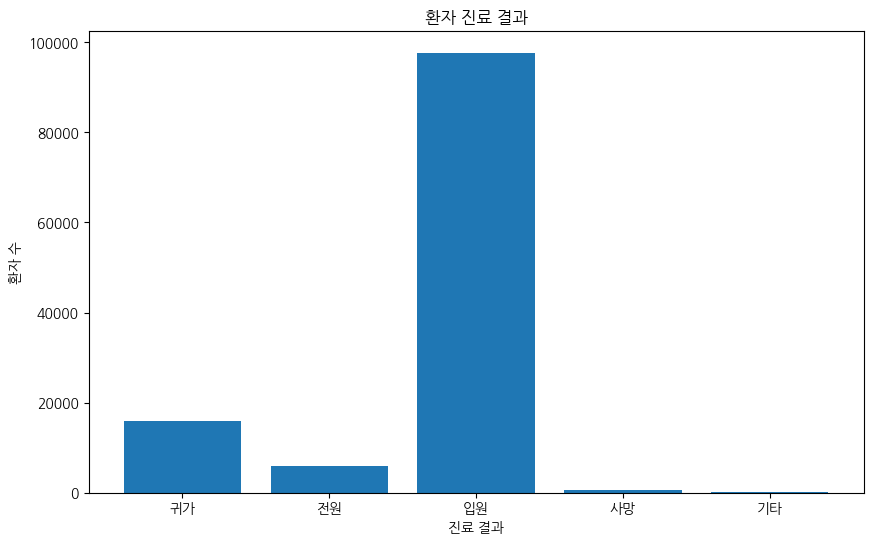

In [ ]:
# 바차트 생성
plt.figure(figsize=(10, 6))
plt.bar(labels, data)
plt.title("환자 진료 결과")
plt.xlabel("진료 결과")
plt.ylabel("환자 수")
plt.show()

## 뇌졸중_환자의_발병_후_응급실_도착_소요시간

In [ ]:
time = df=pd.read_csv('/content/뇌졸중_환자의_발병_후_응급실_도착_소요시간_현황_시도별__20230817135826.csv')
time.head()

,지역별(1),2021,2021.1,2021.2,2021.3,2021.4,2021.5,2021.6
0,지역별(1),계,1시간 미만,1~2시간 미만,2~3시간 미만,3~6시간 미만,6시간 이상,미상/미입력
1,전체,120305,19991,19009,9362,14790,56496,657
2,서울,25348,3902,3266,1732,2893,13505,50
3,부산,6868,997,1287,522,853,2993,216
4,대구,7686,1217,996,588,939,3855,91


In [ ]:
df_time = time.rename(columns={'2021':'계','2021.1':'1시간 미만','2021.2':'1~2시간 미만','2021.3':'2~3시간 미만','2021.4':'3~6시간 미만','2021.5':'6시간 이상','2021.6':'미상'})
df_time.drop(columns='지역별(1)', inplace= True)

In [ ]:
filtered_data = df_time.iloc[[1]]
filtered_data

,계,1시간 미만,1~2시간 미만,2~3시간 미만,3~6시간 미만,6시간 이상,미상
1,120305,19991,19009,9362,14790,56496,657


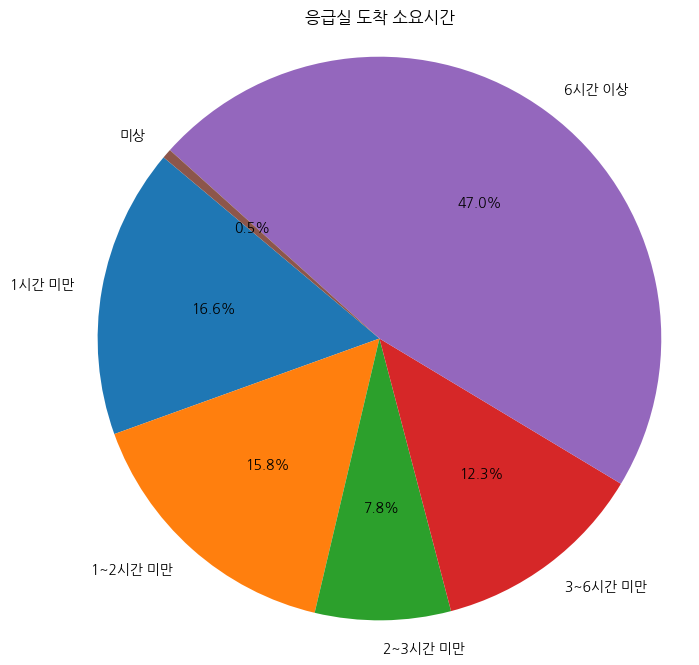

In [ ]:
import matplotlib.pyplot as plt

# 데이터
data = [19991, 19009	, 9362, 14790, 56496, 657]

# 레이블
labels = ['1시간 미만', '1~2시간 미만', '2~3시간 미만', '3~6시간 미만', '6시간 이상','미상']

# 파이차트 생성
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # 파이차트를 원형으로 만듦
plt.title("응급실 도착 소요시간")
plt.show()

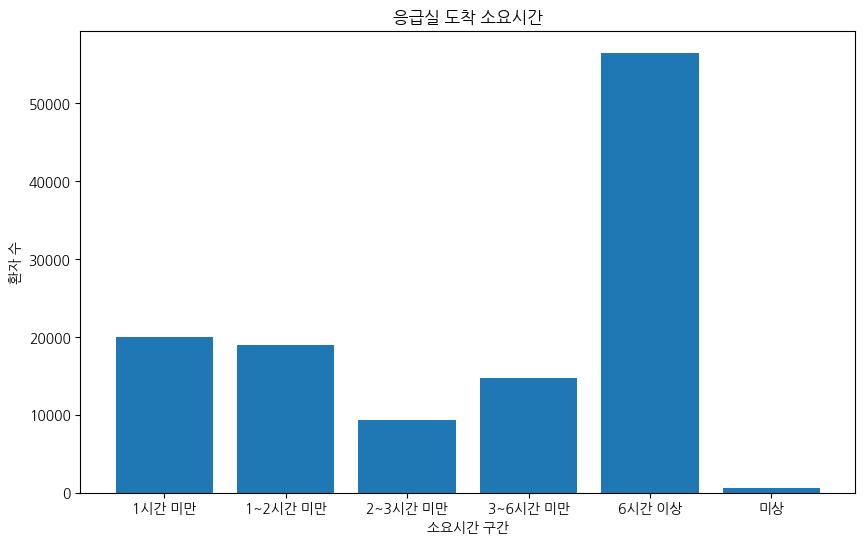

In [ ]:
# 바차트 생성
plt.figure(figsize=(10, 6))
plt.bar(labels, data)
plt.title("응급실 도착 소요시간")
plt.xlabel("소요시간 구간")
plt.ylabel("환자 수")
plt.show()

## 뇌졸중_중풍__조기증상_인지율

In [ ]:
symptom = df=pd.read_csv('/content/시·군·구별_뇌졸중_중풍__조기증상_인지율_20230817135917.csv')
symptom

,시군구별(1),시군구별(2),시군구별(3),2022,2022.1,2022.2,2022.3,2022.4
0,시군구별(1),시군구별(2),시군구별(3),응답자수 (명),조율 (%),조율표준오차,표준화율 (%),표준화율표준오차
1,서울특별시,소계,소계,21816,55.7,0.4,54.0,0.4
2,서울특별시,강남구,소계,898,61.4,1.6,58.3,1.7
3,서울특별시,강동구,소계,921,67.5,1.7,65.1,1.8
4,서울특별시,강북구,소계,747,60.8,2.1,58.3,2.2
...,...,...,...,...,...,...,...,...
288,제주특별자치도,서귀포시,서부,616,69.1,4.7,66.6,2.8
289,제주특별자치도,제주시,소계,1955,74.5,1.5,73.2,1.5
290,제주특별자치도,제주시,제주,662,75.2,1.9,73.6,1.9
291,제주특별자치도,제주시,동부,698,67.0,2.8,63.9,2.3


In [ ]:
symptom_df = symptom.loc[symptom['시군구별(2)']=='소계']
symptom_df

,시군구별(1),시군구별(2),시군구별(3),2022,2022.1,2022.2,2022.3,2022.4
1,서울특별시,소계,소계,21816,55.7,0.4,54.0,0.4
27,부산광역시,소계,소계,14251,58.3,0.5,57.6,0.6
44,대구광역시,소계,소계,7034,62.9,0.7,61.9,0.7
53,인천광역시,소계,소계,8833,55.7,0.7,54.8,0.7
64,광주광역시,소계,소계,4530,52.8,0.8,52.1,0.8
70,대전광역시,소계,소계,4521,57.1,0.9,55.5,0.9
76,울산광역시,소계,소계,4040,59.5,0.8,57.4,0.9
82,세종특별자치시,소계,소계,917,73.5,1.8,71.8,1.7
84,경기도,소계,소계,41818,55.6,0.3,54.4,0.3
143,강원도,소계,소계,15444,55.8,0.7,56.6,0.7


In [ ]:
avg= sum(symptom_df['2022.3'])/len(symptom_df['2022.3'])
avg

TypeError: ignored

In [ ]:
import pandas as pd

# 데이터프레임 읽기, 첫 번째 행은 열 이름이 아닌 데이터이므로 제외하고 읽음
symptom = pd.read_csv('/content/시·군·구별_뇌졸중_중풍__조기증상_인지율_20230817135917.csv', skiprows=[1])

# 데이터프레임 출력
print(symptom.head())
print(symptom.dtypes)

## 사망장소


In [ ]:
die= pd.read_csv('/content/뇌졸중_환자의_사망장소_성별_연령별__20230820184746.csv')
die

In [ ]:
df_die = die.rename(columns={'2017':'계','2017.1':'주택','2017.3':'사회복지시설','2017.4':'공공시설',
                               '2017.5':'도로','2017.6':'상업서비스시설','2017.7':'산업장','2017.8':'농장',
                               '2017.9':'병원이송중','2017.10':'기타','2017.11':'미상'})
df_die.drop(columns=['성별(1)','연령별(1)','2017.2'], inplace= True)

In [ ]:
df_die

In [ ]:
10601-10095

In [ ]:
filtered_data = df_die.iloc[[1]]
filtered_data

In [ ]:
# 데이터
data = [299, 153, 2, 2, 3, 2,5,16,21,3]

# 레이블
labels = ['주택', '사회복지시설', '공공시설', '도로', '상업서비스시설','산업장','농장','병원이송중','기타','미상']

# 파이차트 생성
plt.figure(figsize=(10, 10))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # 파이차트를 원형으로 만듦
plt.title("뇌졸중 환자의 사망장소")
plt.show()

In [ ]:
# 바차트 생성
plt.figure(figsize=(10, 6))
plt.bar(labels, data)
plt.title("뇌졸중 환자의 사망장소")
plt.xlabel("사망장소")
plt.ylabel("환자 수")
plt.show()

# 뇌졸중 판별 데이터 학습

In [ ]:
# 필요 라이브러리 임포트
!pip install cmake

!pip install dlib
!pip install imutils
!pip install opencv-python

from google.colab.patches import cv2_imshow # Google Colab에서 이미지 출력을 위한 함수

from imutils import face_utils  # dlib에서 사용하는 페이셜 유틸리티 함수
import numpy as np # 다차원 배열 데이터 처리를 위한 라이브러리
import imutils # 이미지 처리를 위한 함수를 제공하는 라이브러리
import dlib  # 얼굴 인식과 랜드마크 검출을 위한 라이브러리
import cv2  # 영상 처리를 위한 라이브러리입니다.

# 입력 이미지의 얼굴 전체를 검출하여 랜드마크를 그리는 함수
def show_raw_detection(image, detector, predictor):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # 이미지를 회색으로 변경

  rects = detector(gray, 1) # 회색으로 바꾼 이미지를 검출기에 넣음.

  for(i, rect) in enumerate(rects):
    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape) # 검출한 얼굴 영역에서 랜드마크 검출.

    (x,y,w,h) = face_utils.rect_to_bb(rect)
    cv2.rectangle(image, (x,y), (x+w, y+h), (0,255,0),2) # 검출된 얼굴 영역을 사각형으로 표시.

    cv2.putText(image, "Face #{}".format(i+1), (x -10, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2) # 각 얼굴 영역에 번호를 부여해서 출력
    for(x,y) in shape:
      cv2.circle(image, (x,y), 1, (0, 0, 255), -1) # 검출된 랜드마크 출력

  cv2_imshow(image) # 사진 출력
  cv2.waitKey(0)


# 입력 이미지의 부위 별 이미지를 검출하여 그리는 함수
def draw_individual_detections(image, detector, predictor):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # 이미지를 회색으로 변경

  rects = detector(gray,1) # 회색으로 바꾼 이미지를 검출기에 넣음.

  for(i, rect) in enumerate(rects):

    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape)  # 얼굴 랜드마크 좌표값을 numpy 배열로 변환


    for(name, (i,j)) in face_utils.FACIAL_LANDMARKS_IDXS.items():
      clone = image.copy()  # 이미지를 복사
      cv2.putText(clone, name, (10,30),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255),2) # 랜드마크 이름을 출력

      for(x,y) in shape[i:j]: # 현재 랜드마크 영역내의 모든 좌표에 대해 반복
        cv2.circle(clone, (x,y), 1, (0,0,255), -1)  # 검출된 랜드마크를 출력

      (x,y,w,h) = cv2.boundingRect(np.array([shape[i:j]]))# 현재 랜드마크 영역의 경계 사각형을 구함
      roi = image[y : y+h, x : x+w] # 랜드마크를 검출한 얼굴 영역을 자름
      roi = imutils.resize(roi, width = 250, # 잘라낸 영역의 크기를 조정
                           inter = cv2.INTER_CUBIC)

      cv2_imshow(roi) # 잘라낸 영역을 출력
      cv2_imshow(clone) # 랜드마크를 표시한 이미지를 출력
      cv2.waitKey(0)  # 아무 키나 누르면 종료
    output = face_utils.visualize_facial_landmarks(image, shape) # 랜드마크를 시각화한 이미지를 출력
    cv2_imshow(output)
    cv2.waitKey(0)

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')
image = cv2.imread('/content/KakaoTalk_20230819_171831560.png')
image = imutils.resize(image, width = 500)

# 이미지 파일을 불러서 얼굴 영역을 검출
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
rects = detector(gray, 1)

# 검출된 얼굴 영역 중에서 최초의 하나만 사용
# 만약 여러 개의 얼굴 영역이 검출된다면 다른 방법
for (i, rect) in enumerate(rects):
    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape)

    # "Mouth" 라는 이름을 가진 랜드마크 영역에 대한 좌표값
    # 48번 랜드마크부터 68번 랜드마크까지가 "Mouth" 영역
    mouth_coords = shape[48:68]

# mouth_coords에는 입술 랜드마크 좌표값
# 만약 이 좌표값이 2차원 배열 형태로 필요하다면 아래와 같이 처리
mouth_coords = np.array(mouth_coords)

import pandas as pd

# 얼굴 검출을 위한 dlib의 face detector 객체 생성
detector = dlib.get_frontal_face_detector()
# 68개 얼굴 랜드마크 예측 모델 로드
predictor = dlib.shape_predictor('/content/shape_predictor_68_face_landmarks.dat')

# 입술의 랜드마크 좌표 추출을 위한 함수 정의
def get_lip_landmarks(image):
    # 이미지를 RGB로 변환
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # 이미지의 gray 변환
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # 얼굴 검출 수행
    rects = detector(gray, 1)
    # 입술 랜드마크 좌표 추출
    if len(rects)>0:
        shape = predictor(gray, rects[0])
        shape = face_utils.shape_to_np(shape)
        lip_points = [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67]
        lip_landmarks = np.array([shape[idx] for idx in lip_points])
        return lip_landmarks.flatten()
    else:
        return None

# 데이터프레임 생성을 위한 리스트 객체 생성
features = []
results = []

# 이미지 데이터셋의 경로(여기서는 "/content/images" 폴더 내에 있는 이미지들을 사용)
import os
path_to_images = "/content/images2"

for file_name in os.listdir(path_to_images):
    # 이미지를 읽어온 뒤 facelandmark를 추출
    image = cv2.imread(os.path.join(path_to_images, file_name))
    landmarks = get_lip_landmarks(image)
    if landmarks is not None:
        # facelandmark를 features 리스트 객체에 추가
        features.append(landmarks)
        # 결과값(1)을 results 리스트 객체에 추가
        results.append(1)

path_to_images = "/content/images"
for file_name in os.listdir(path_to_images):
    # 이미지를 읽어온 뒤 facelandmark를 추출
    image = cv2.imread(os.path.join(path_to_images, file_name))
    landmarks = get_lip_landmarks(image)
    if landmarks is not None:
        # facelandmark를 features 리스트 객체에 추가
        features.append(landmarks)
        # 결과값(1)을 results 리스트 객체에 추가
        results.append(0)

# features와 results를 이용하여 데이터프레임 생성
df = pd.DataFrame(features)
df['result'] = results
df.columns = ['feature_' + str(i) for i in range(len(df.columns)-1)] + ['result']


from sklearn.model_selection import train_test_split

X = df.drop('result', axis=1)
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=77)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)


import numpy as np
from keras.utils import to_categorical
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.models import Sequential

# 데이터 생성
X_train = np.random.rand(218, 40)
y_train = np.random.randint(2, size=218)
y_train = to_categorical(y_train)

# 모델 구성
model = Sequential()
model.add(Conv1D(64, 3, input_shape=(40, 1), activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(2, activation='softmax'))

# 모델 설정
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# X_train 데이터 Shape 변환
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# 모델 학습
model.fit(X_train, y_train, epochs=25, batch_size=32)

# 입력 데이터 reshape
mouth_coords = mouth_coords.reshape((1, 40, 1))

# 모델 예측
prediction = model.predict(mouth_coords, batch_size=None)

if prediction[0][0] > prediction[0][1]:
    print("예측 결과: 이 이미지는 클래스 0입니다.")
else:
    print("예측 결과: 이 이미지는 클래스 1입니다.")

num_classes = 2 # 분류하려는 클래스의 개수

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

y_pred = (model.predict(X_test) > 0.5).astype("int32")   # 출력값을 0 또는 1의 형태로 변환

# y_test_binary 배열을 이진 벡터로 변환
y_test_binary = np.zeros((len(y_pred), num_classes))
for i in range(y_pred.shape[0]):
    y_test_binary[i, y_test[i]] = 1

# 분류 정확도 계산
accuracy = np.mean(y_pred == y_test_binary)
print("Accuracy:", accuracy)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import time

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();


      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);


      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

count = 1

while True:
    filename = f"photo_{count}.jpg"
    print(f"사진 저장 중: {filename}")
    take_photo(filename)  # 사진 찍기
    time.sleep(2)
    count += 1

take_photo()